## Imports et connexion

In [2]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

In [3]:
load_dotenv(dotenv_path="../../.env")

# Connexion et chargement dans Pandas
conn = psycopg2.connect(
    host="localhost",
    port="5432",
    database="datapulse_db",
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD")
)

query = """
SELECT t.filename, t.source_dataset, t.size_bytes, t.duration_seconds, i.label_name as instrument
FROM audio_tracks t
JOIN instruments i ON t.instrument_id = i.id;
"""
df = pd.read_sql(query, conn)
conn.close()

# Conversion en MB pour la normalisation (C2.1)
df['size_mb'] = df['size_bytes'] / (1024 * 1024)
print(f"{len(df)} pistes chargées avec succès depuis PostgreSQL Gold !")

23262 pistes chargées avec succès depuis PostgreSQL Gold !


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_28380\4183522560.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


## Analyses statistiques (C2.1 & 2.2)

### Recherche des valeurs manquantes

In [10]:
def analyse_missing_data(df) :
    missing = df.isnull().sum()
    missing_pct = 100 * missing / len(df)

    missing_table = pd.DataFrame({
        "Colonnes" : missing.index,
        "Valeurs manquantes" : missing.values,
        "Pourcentage" : missing_pct.values
    })

    missing_table = missing_table[missing_table["Valeurs manquantes"] > 0]. sort_values("Pourcentage", ascending=False)

    return missing_table

missing_data = analyse_missing_data(df)
missing_data

,Colonnes,Valeurs manquantes,Pourcentage


#### Suppression des 2 valeurs manquantes trouvées

In [11]:
df = df.dropna(subset=['duration_seconds'])
missing_data

,Colonnes,Valeurs manquantes,Pourcentage


In [13]:
df = df[df['instrument'] != 'unknown']

In [14]:
print(df)

                                  filename      source_dataset  size_bytes  \
0      banjo_A3_very-long_forte_normal.mp3  philharmonia_scrap       43779   
1      banjo_A3_very-long_piano_normal.mp3  philharmonia_scrap       44093   
2      banjo_A4_very-long_forte_normal.mp3  philharmonia_scrap       47855   
3      banjo_A4_very-long_piano_normal.mp3  philharmonia_scrap       40018   
4      banjo_A5_very-long_forte_normal.mp3  philharmonia_scrap       48481   
...                                    ...                 ...         ...   
23257            [voi][pop_roc]2547__2.wav       irmas_dataset      529240   
23258            [voi][pop_roc]2547__3.wav       irmas_dataset      529240   
23259            [voi][pop_roc]2548__1.wav       irmas_dataset      529240   
23260            [voi][pop_roc]2548__2.wav       irmas_dataset      529240   
23261            [voi][pop_roc]2548__3.wav       irmas_dataset      529240   

       duration_seconds instrument   size_mb format  
0        

### Statistiques des données
#### Analyse univariée

In [17]:
print("=== Statistiques de la taille des fichiers===")
display(round(df['size_mb'].describe(), 4))

=== Statistiques de la taille des fichiers===


count    22533.0000
mean         0.4972
std          0.9469
min          0.0026
25%          0.0112
50%          0.0229
75%          0.5047
max          3.3646
Name: size_mb, dtype: float64

In [18]:

print("=== Statistiques de la durée des fichiers===")
display(round(df['duration_seconds'].describe(), 4))

=== Statistiques de la durée des fichiers===


count    22533.0000
mean         4.1671
std          5.7382
min          0.2529
25%          1.1256
50%          2.2933
75%          3.0000
max         77.8654
Name: duration_seconds, dtype: float64

In [19]:
print("=== Fréquences absolues (Nombre de pistes) ===")
comptage = df['instrument'].value_counts()
display(comptage.to_frame(name='Nombre de pistes'))

=== Fréquences absolues (Nombre de pistes) ===


,Nombre de pistes
instrument,
clarinet,1825
electric_guitar,1600
violin,1502
piano,1501
saxophone,1370
acoustic_guitar,1166
trumpet,1076
voice,1059
viola,973


In [20]:
print("=== Fréquences relatives (Pourcentages) ===")
pourcentage = df['instrument'].value_counts(normalize=True) * 100
display(pourcentage.to_frame(name='Proportion (%)').round(2))

=== Fréquences relatives (Pourcentages) ===


,Proportion (%)
instrument,
clarinet,8.10
electric_guitar,7.10
violin,6.67
piano,6.66
saxophone,6.08
acoustic_guitar,5.17
trumpet,4.78
voice,4.70
viola,4.32


C:\Users\Administrateur\AppData\Local\Temp\ipykernel_28944\551018269.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='instrument', order=df['instrument'].value_counts().index, palette='viridis')


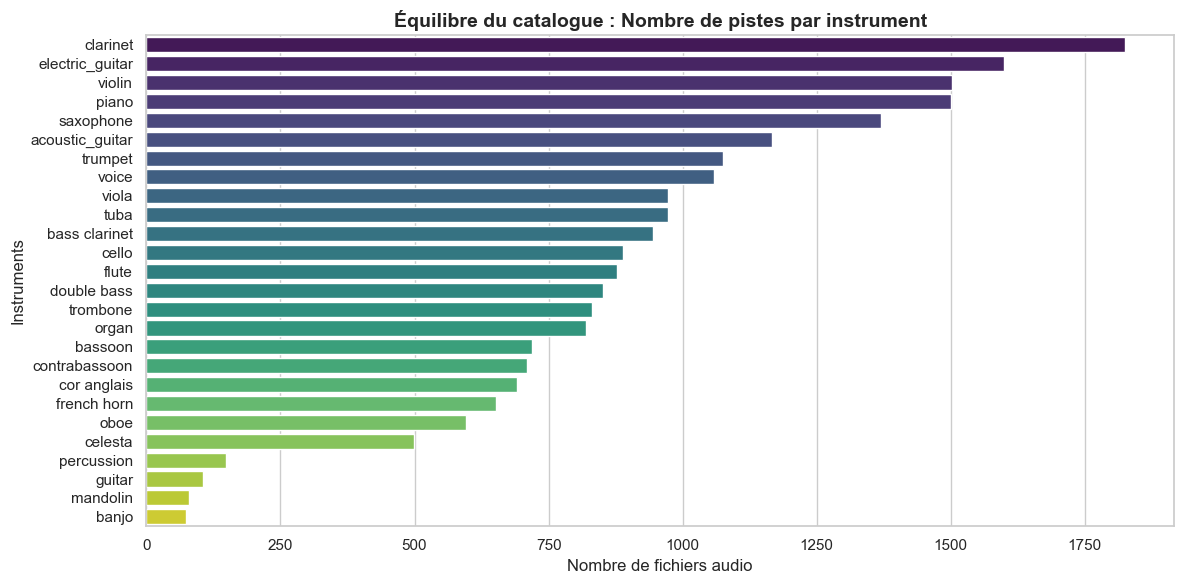

In [21]:
# Configuration esthétique globale
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- GRAPHICS 1 : Répartition des instruments (C2.4) ---
plt.figure()
sns.countplot(data=df, y='instrument', order=df['instrument'].value_counts().index, palette='viridis')
plt.title("Équilibre du catalogue : Nombre de pistes par instrument", fontsize=14, fontweight='bold')
plt.xlabel("Nombre de fichiers audio")
plt.ylabel("Instruments")
plt.tight_layout()
plt.show()

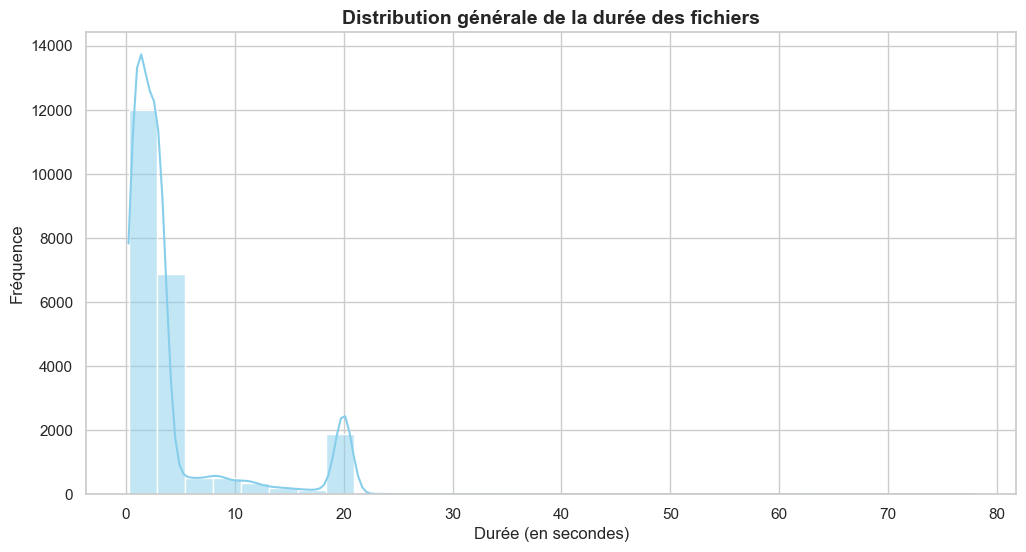

In [22]:
# --- GRAPHICS 2 : Distribution de la durée (C2.1 / C2.4) ---
plt.figure()
sns.histplot(data=df, x='duration_seconds', kde=True, bins=30, color='skyblue')
plt.title("Distribution générale de la durée des fichiers", fontsize=14, fontweight='bold')
plt.xlabel("Durée (en secondes)")
plt.ylabel("Fréquence")
plt.show()

C:\Users\Administrateur\AppData\Local\Temp\ipykernel_28944\1121986795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='instrument', y='duration_seconds', palette='Set2')


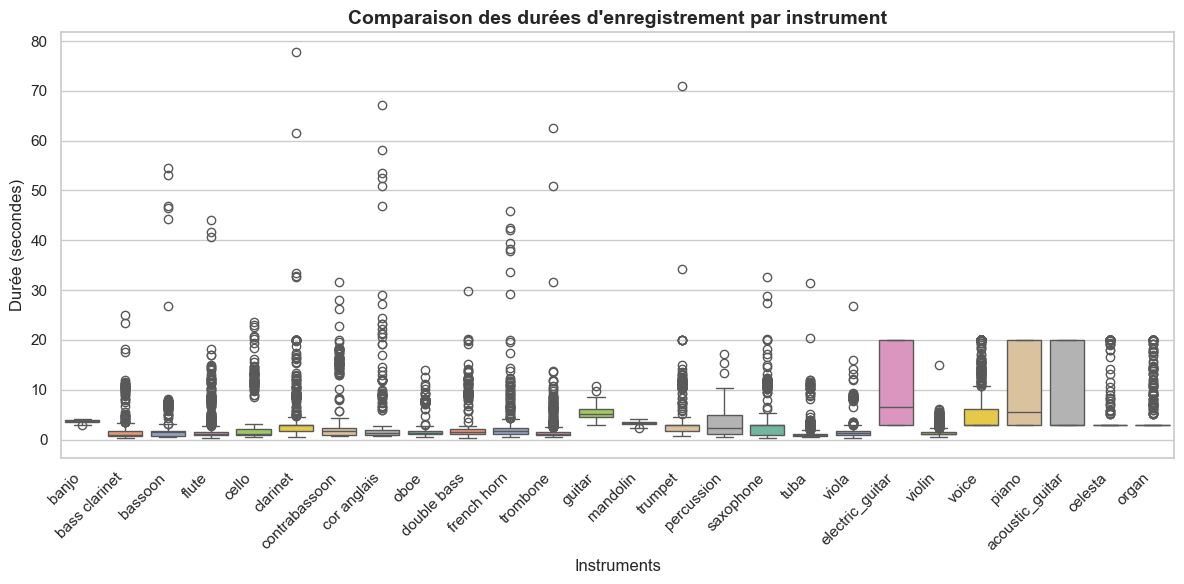

In [23]:
# --- GRAPHICS 3 : Boxplot Multivarié (C2.2) ---
plt.figure()
sns.boxplot(data=df, x='instrument', y='duration_seconds', palette='Set2')
plt.title("Comparaison des durées d'enregistrement par instrument", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Instruments")
plt.ylabel("Durée (secondes)")
plt.tight_layout()
plt.show()

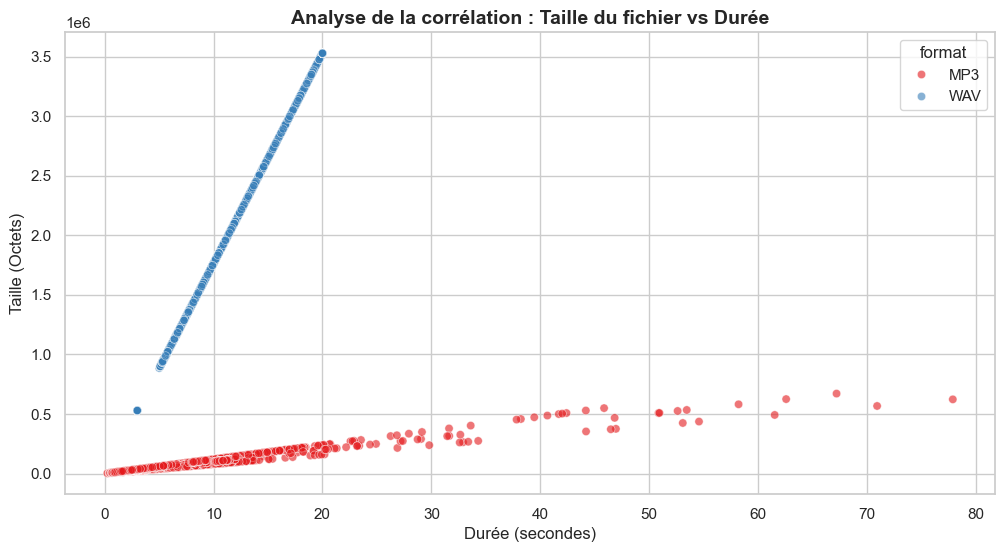

In [24]:
# --- GRAPHICS 4 : Scatter Plot Taille vs Durée (C2.2) ---
# On extrait l'extension pour l'affichage (.wav ou .mp3)
df['format'] = df['filename'].apply(lambda x: x.split('.')[-1].upper())

plt.figure()
sns.scatterplot(data=df, x='duration_seconds', y='size_bytes', hue='format', alpha=0.6, palette='Set1')
plt.title("Analyse de la corrélation : Taille du fichier vs Durée", fontsize=14, fontweight='bold')
plt.xlabel("Durée (secondes)")
plt.ylabel("Taille (Octets)")
plt.show()

### Analyse multivariée

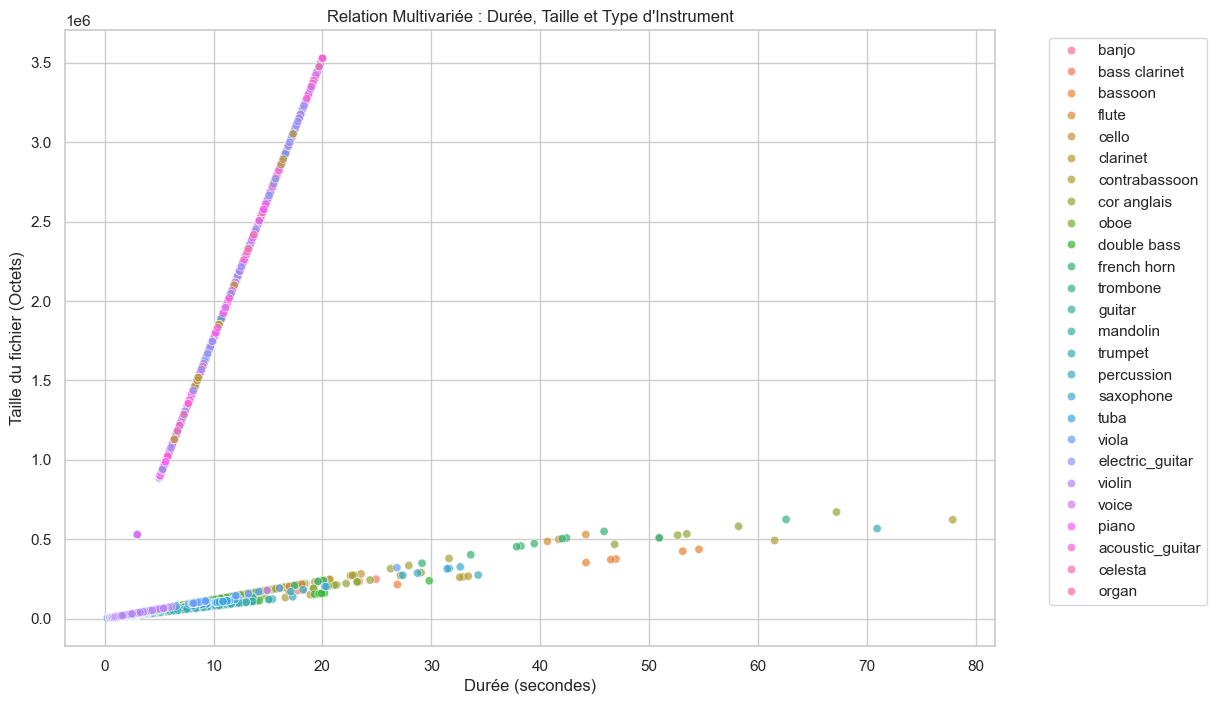

In [25]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df, 
    x='duration_seconds', 
    y='size_bytes', 
    hue='instrument', 
    alpha=0.7
)
plt.title("Relation Multivariée : Durée, Taille et Type d'Instrument")
plt.xlabel("Durée (secondes)")
plt.ylabel("Taille du fichier (Octets)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

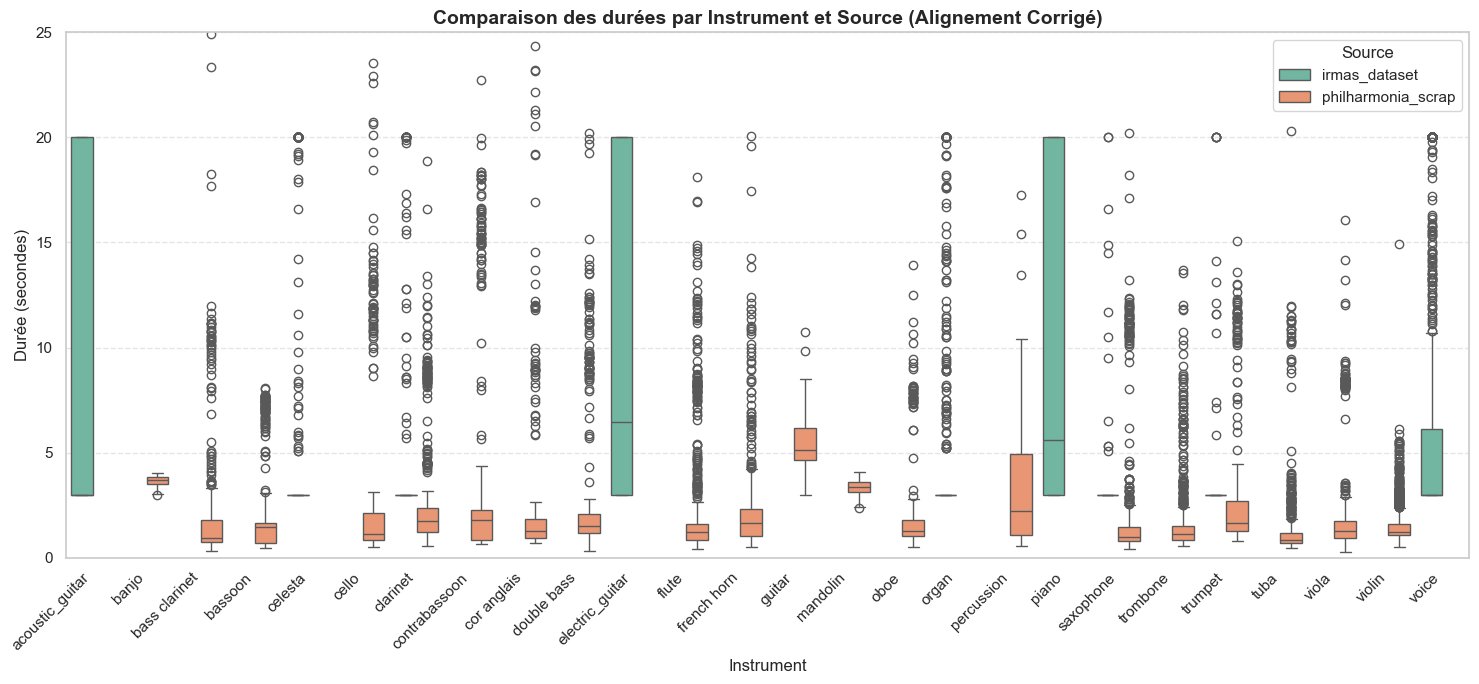

In [34]:
# 1. On trie le DataFrame par instrument pour aligner l'axe X proprement
df_sorted = df.sort_values(by='instrument')

plt.figure(figsize=(15, 7))

# 2. On trace en utilisant le DataFrame trié
sns.boxplot(
    data=df_sorted, 
    x='instrument', 
    y='duration_seconds', 
    hue='source_dataset',
    palette='Set2',
    dodge=True,     # On garde ça pour éviter l'écrasement des boîtes
)

plt.ylim(0, 25)
plt.xticks(rotation=45, ha='right') # 'ha=right' aligne le texte EXACTEMENT sous le trait de l'axe

plt.title("Comparaison des durées par Instrument et Source (Alignement Corrigé)", fontsize=14, fontweight='bold')
plt.xlabel("Instrument", fontsize=12)
plt.ylabel("Durée (secondes)", fontsize=12)
plt.legend(title="Source", loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

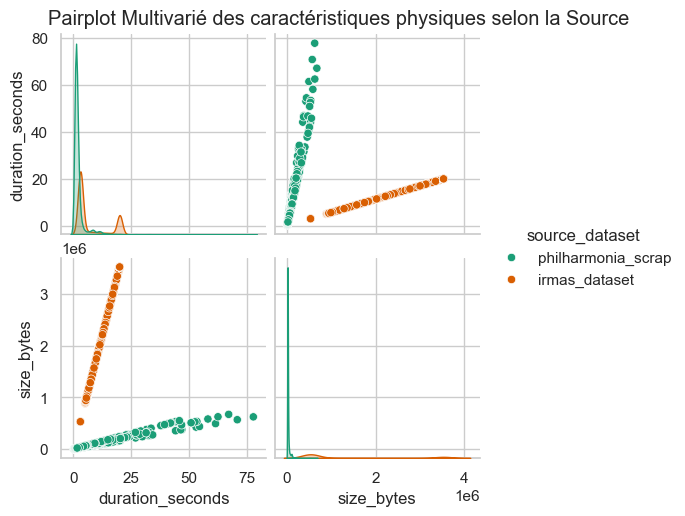

In [30]:
columns_to_plot = ['duration_seconds', 'size_bytes', 'source_dataset']

sns.pairplot(
    df[columns_to_plot], 
    hue='source_dataset', 
    diag_kind='kde', 
    palette='Dark2'
)
plt.suptitle("Pairplot Multivarié des caractéristiques physiques selon la Source", y=1.02)
plt.show()